In [1]:
import os
os.chdir('..')

## 1. Load Checkpoint

In [2]:
from src.backtest import load_ticker_data, load_qfunc_from_checkpoint, run_backtest
from src.plots import *

In [3]:
model_name = "SHARED_LAMBDA_OPTIMIZATION_EPSGREEDY_16PATHS"
runtime_folder = "20260415_014139"
checkpoint_file = "checkpoint_ep5.pt"

TICKER       = 'SPY'
START_DATE   = '2024-01-01'
END_DATE     = '2025-12-31'
RF_RATE      = 0.024   # annualised risk-free rate (continuous compounding)
TRANS_COST   = 0.0005  # transaction cost as fraction of position change

In [4]:
config_path = os.path.join(
    os.getcwd(), "runs", model_name, runtime_folder, "config.json"
)
checkpoint_path = os.path.join(
    os.getcwd(), "runs", model_name, runtime_folder, "checkpoints", checkpoint_file
)

ckpt = load_qfunc_from_checkpoint(config_path, checkpoint_path)
qfunc = ckpt['qfunc']
action_values = ckpt['action_values']

print(f'action_values: {action_values}')

action_values: [-1.   -0.75 -0.5  -0.25  0.    0.25  0.5   0.75  1.  ]


# 2. Single Seed Backtest

In [5]:
df = load_ticker_data(TICKER, START_DATE, END_DATE)

result = run_backtest(
    qfunc, action_values,
    rf_rate=RF_RATE,
    trans_cost=TRANS_COST,
    df=df,
)

dates = result['dates']
agent_r = result['agent_log_returns']
bm_r = result['benchmark_log_returns']
positions = result['positions']

print(f'Period: {dates[0].date()} → {dates[-1].date()}  ({len(dates)} trading days)')
print(f'Final agent wealth:     {result["agent_wealth"][-1]:.4f}')
print(f'Final benchmark wealth: {result["benchmark_wealth"][-1]:.4f}')

[*********************100%***********************]  1 of 1 completed

Period: 2024-04-03 → 2025-12-31  (439 trading days)
Final agent wealth:     0.8304
Final benchmark wealth: 1.3426


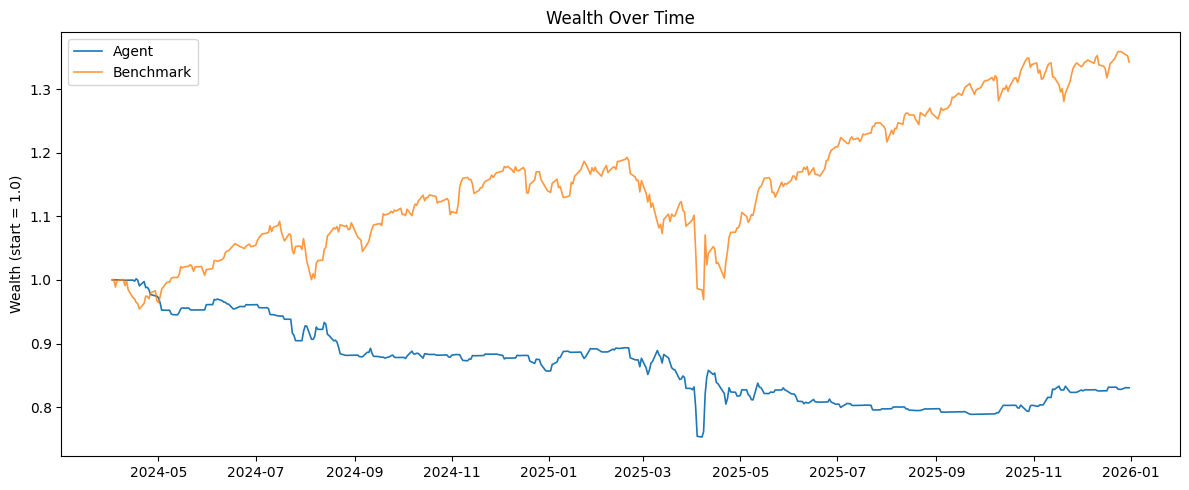

In [6]:
fig = plot_wealth(dates, agent_r, benchmark_log_returns=bm_r)
plt.show()

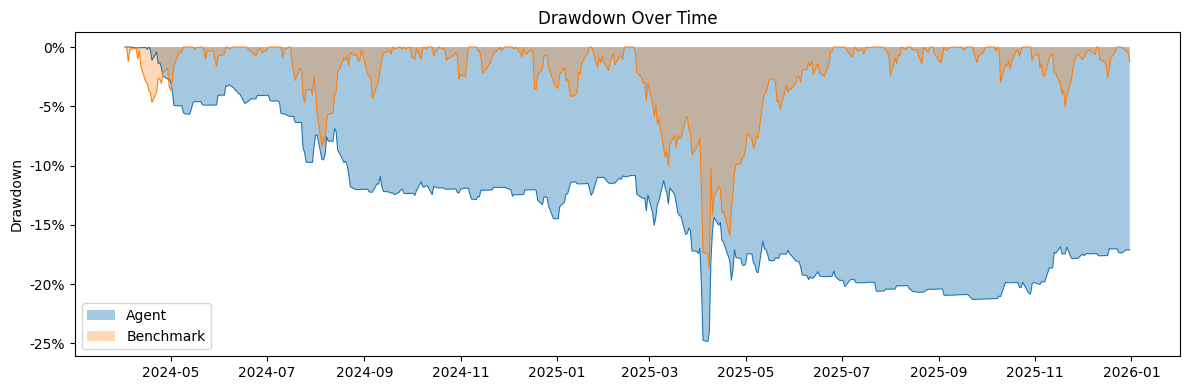

In [7]:
fig = plot_drawdown(dates, agent_r, benchmark_log_returns=bm_r)
plt.show()

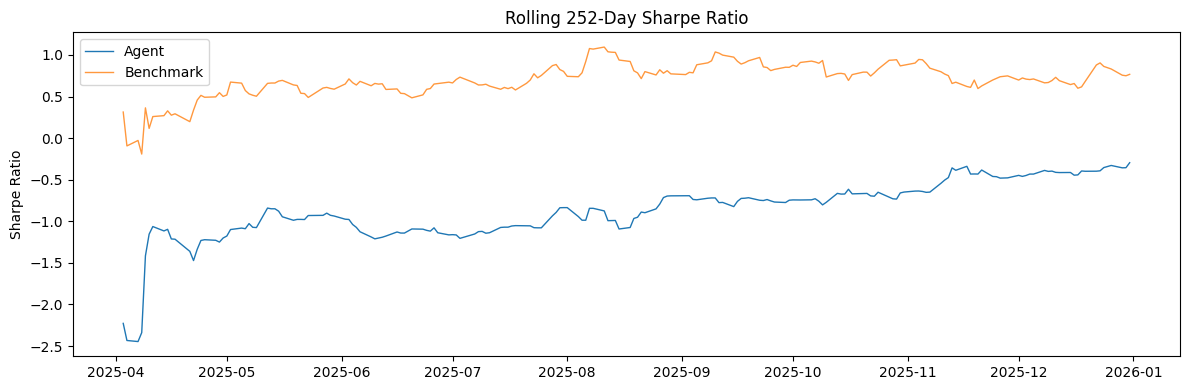

In [8]:
fig = plot_rolling_sharpe(dates, agent_r, benchmark_log_returns=bm_r, window=252)
plt.show()

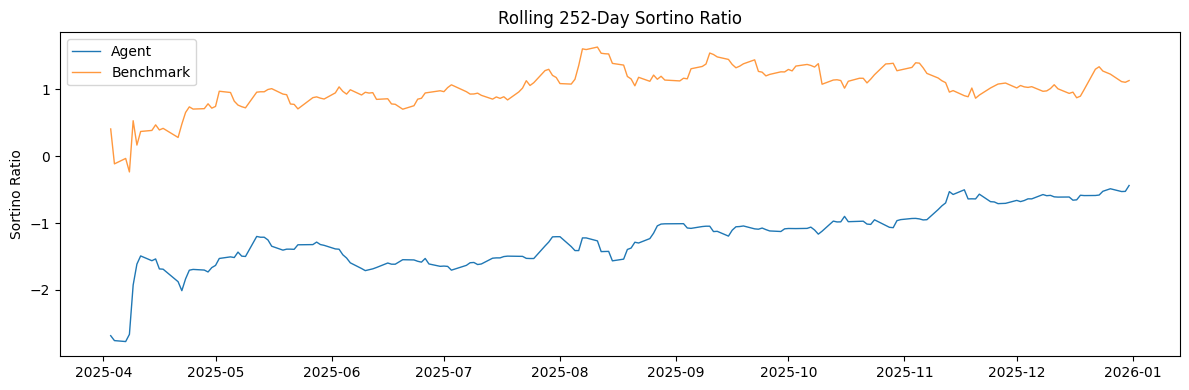

In [9]:
fig = plot_rolling_sortino(dates, agent_r, benchmark_log_returns=bm_r, window=252)
plt.show()

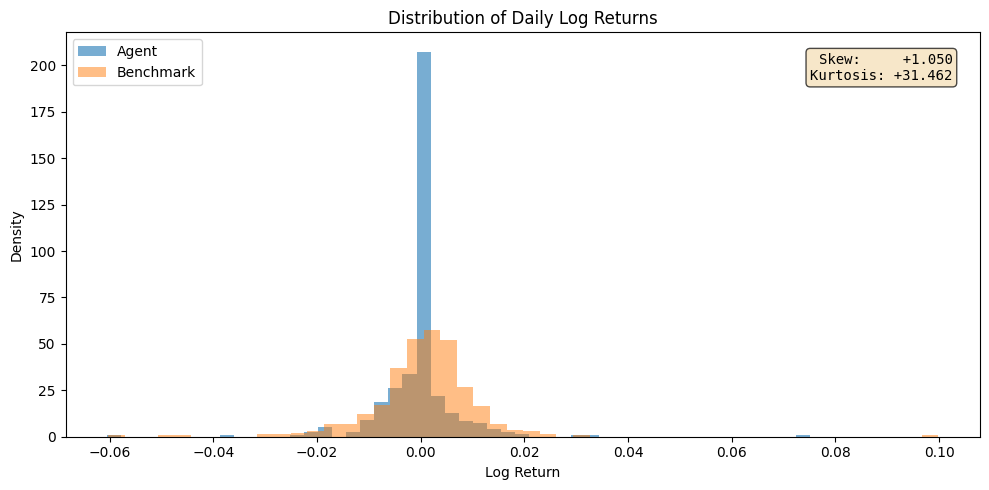

In [10]:
fig = plot_return_distribution(agent_r, benchmark_log_returns=bm_r)
plt.show()

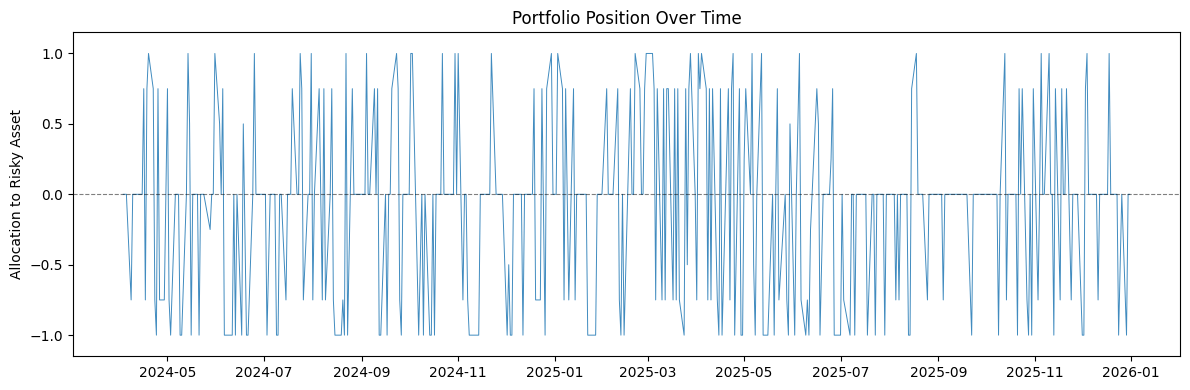

In [11]:
fig = plot_position(dates, positions)
plt.show()

# 3. Multiple Seeds Backtest

In [12]:
# Each entry: (runtime_folder, checkpoint_file)
SEED_CHECKPOINTS = [
    ('20260415_014139', 'checkpoint_ep5.pt'),
    ('20260415_130200', 'checkpoint_ep5.pt'),
    ('20260415_141820', 'checkpoint_ep5.pt'),
    ('20260415_152907', 'checkpoint_ep5.pt'),
    ('20260415_164347', 'checkpoint_ep5.pt'),
]

# Automatic entry
runtime_folders = [(folder, checkpoint_file) for folder in os.listdir(os.path.join(os.getcwd(), "runs", model_name)) if not '.' in folder]
runtime_folders

[('20260415_014139', 'checkpoint_ep5.pt'),
 ('20260415_130200', 'checkpoint_ep5.pt'),
 ('20260415_141820', 'checkpoint_ep5.pt'),
 ('20260415_152907', 'checkpoint_ep5.pt'),
 ('20260415_164347', 'checkpoint_ep5.pt')]

In [13]:
# df is already loaded from the single-run section above — reuse it here
log_returns_list = []

for runtime_folder, checkpoint_file in SEED_CHECKPOINTS:
    checkpoint_path = os.path.join(
        os.getcwd(), "runs", model_name, runtime_folder, "checkpoints", checkpoint_file
    )
    ckpt_i = load_qfunc_from_checkpoint(config_path, checkpoint_path)
    
    result_i = run_backtest(
        ckpt_i['qfunc'], ckpt_i['action_values'],
        rf_rate=RF_RATE,
        trans_cost=TRANS_COST,
        df=df
    )
    log_returns_list.append(result_i['agent_log_returns'])

dates_ms = result_i['dates']
bm_r_ms  = result_i['benchmark_log_returns']
avg_agent_r = np.mean(log_returns_list, axis=0)
print(f'Loaded {len(log_returns_list)} seed runs.')

Loaded 5 seed runs.


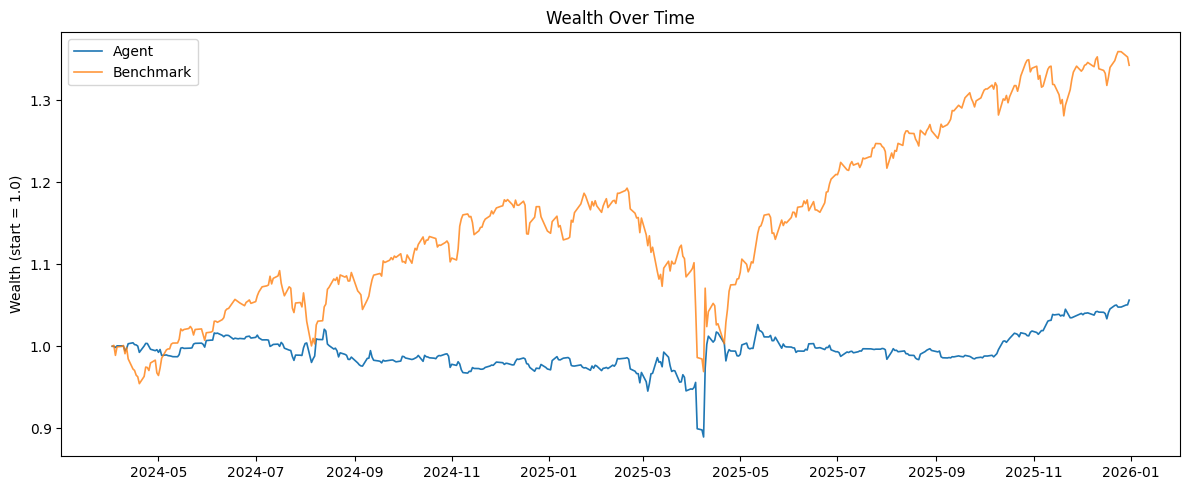

In [14]:
fig = plot_wealth(dates, avg_agent_r, benchmark_log_returns=bm_r)
plt.show()

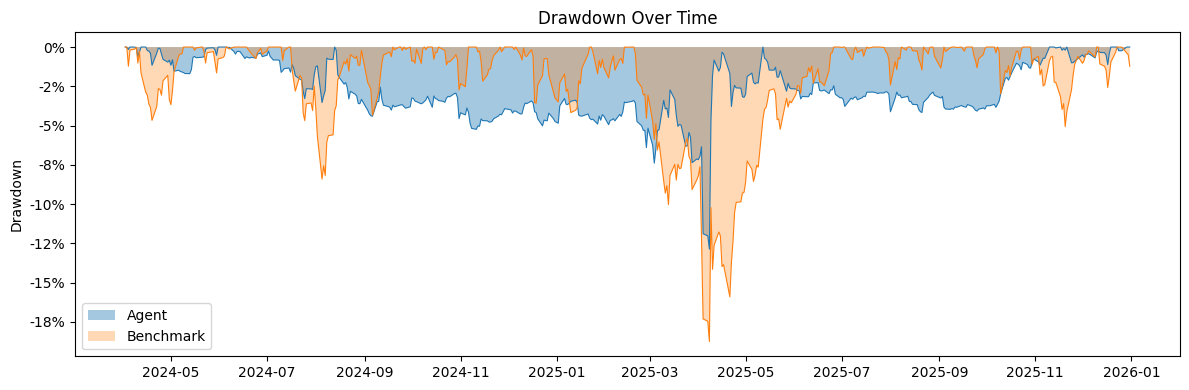

In [15]:
fig = plot_drawdown(dates, avg_agent_r, benchmark_log_returns=bm_r)
plt.show()

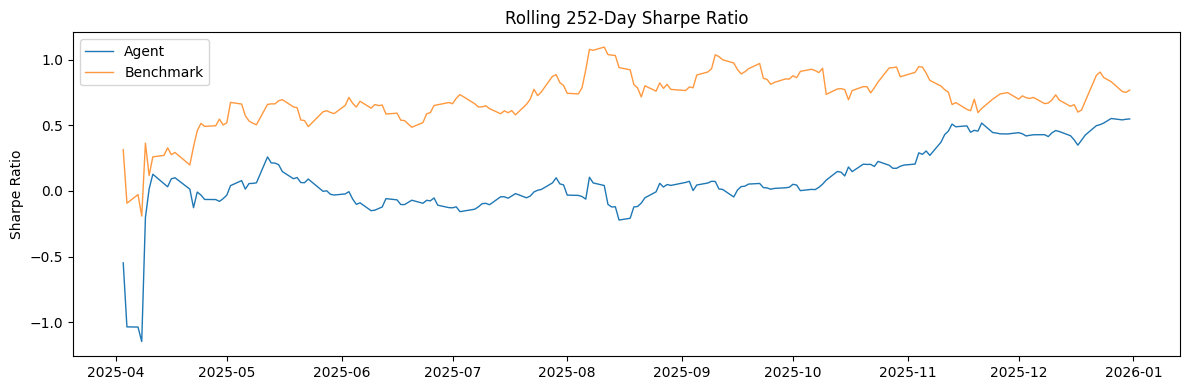

In [16]:
fig = plot_rolling_sharpe(dates, avg_agent_r, benchmark_log_returns=bm_r, window=252)
plt.show()

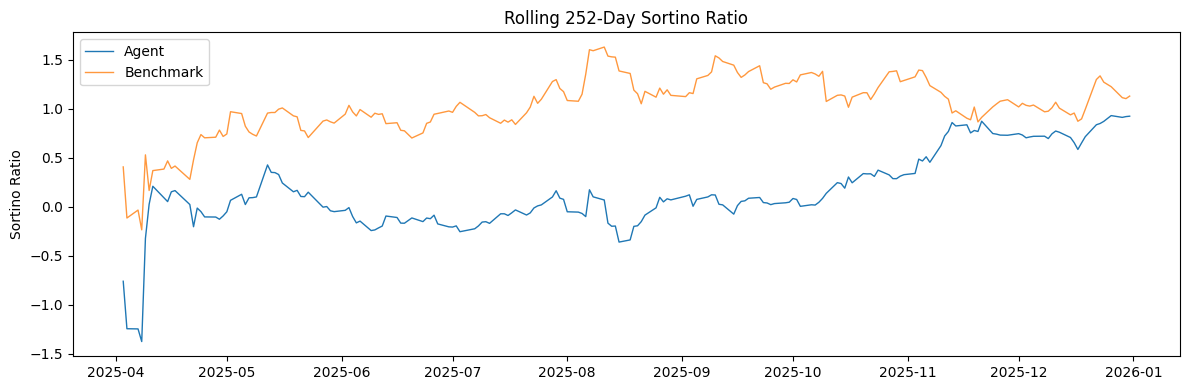

In [17]:
fig = plot_rolling_sortino(dates, avg_agent_r, benchmark_log_returns=bm_r, window=252)
plt.show()

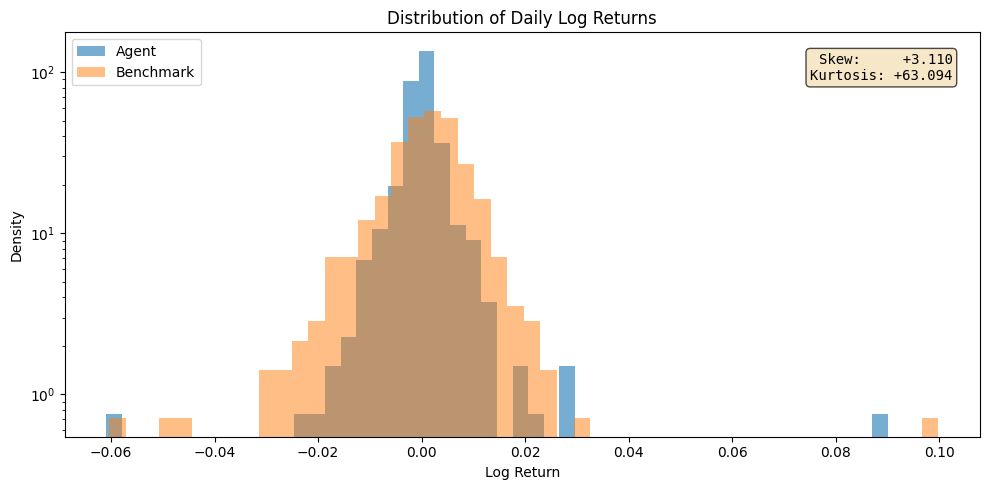

In [18]:
fig = plot_return_distribution(avg_agent_r, benchmark_log_returns=bm_r, is_log_scale=True)
plt.show()